# Customer Segmentation using RFM Analysis

This notebook performs **RFM (Recency, Frequency, Monetary) Analysis** to segment customers based on their purchasing behavior.

RFM analysis helps businesses identify their most valuable customers, understand purchasing patterns, and design targeted marketing strategies to improve customer retention and revenue.

## Project Objectives

The objectives of this notebook are to:

- Load the cleaned Online Retail dataset.
- Calculate Recency, Frequency, and Monetary (RFM) metrics for each customer.
- Assign RFM scores using quintiles.
- Create customer segments based on RFM scores.
- Analyze customer behavior across different segments.
- Generate business insights to support data-driven marketing decisions.

In [2]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Plot style
plt.style.use("default")

## Load Cleaned Dataset

The cleaned dataset prepared in the previous notebook is loaded for customer segmentation analysis.

In [3]:
# Load cleaned dataset

df = pd.read_csv("../data/OnlineRetail_cleaned.csv")

# Display first five rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [4]:
df.shape

(392692, 9)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  int64  
 1   StockCode    392692 non-null  str    
 2   Description  392692 non-null  str    
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  str    
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  int64  
 7   Country      392692 non-null  str    
 8   TotalPrice   392692 non-null  float64
dtypes: float64(2), int64(3), str(4)
memory usage: 50.8 MB


In [6]:
# Check missing values

df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64

### Observations

- The cleaned dataset has no significant missing values.
- CustomerID is available for all remaining transactions.
- The dataset is ready for RFM analysis.

## Convert Invoice Date

Ensure the `InvoiceDate` column is stored in datetime format before calculating customer recency.

In [7]:
# Convert InvoiceDate to datetime

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Verify data type
df["InvoiceDate"].dtype

dtype('<M8[us]')

## Create Snapshot Date

RFM analysis measures customer recency relative to a reference date called the **Snapshot Date**.

The snapshot date is defined as **one day after the most recent transaction** in the dataset.

In [8]:
# Create snapshot date

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Snapshot Date:", snapshot_date)

Snapshot Date: 2023-12-10 12:50:00


### Observation

The snapshot date serves as the reference point for calculating how recently each customer made a purchase.

## Calculate RFM Metrics

RFM Analysis evaluates customer purchasing behavior using three key metrics:

- **Recency (R):** Number of days since the customer's last purchase.
- **Frequency (F):** Total number of unique purchases made by the customer.
- **Monetary (M):** Total amount spent by the customer.

These metrics form the foundation for customer segmentation.

In [9]:
# Calculate RFM metrics

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})

# Rename columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

# Display first five rows
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


### Observation

Each row in the RFM table represents a unique customer and summarizes their purchasing behavior using Recency, Frequency, and Monetary values.

## Explore RFM Metrics

Before assigning RFM scores, let's examine the structure and summary statistics of the RFM dataset.

In [10]:
rfm.shape

(4338, 3)

In [11]:
rfm.info()

<class 'pandas.DataFrame'>
Index: 4338 entries, 12346 to 18287
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4338 non-null   int64  
 1   Frequency  4338 non-null   int64  
 2   Monetary   4338 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 135.6 KB


In [12]:
# Check missing values

rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [13]:
# Statistical summary

rfm.describe().round(2)

,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.54,4.27,2048.69
std,100.01,7.70,8985.23
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,1660.60
max,374.00,209.00,280206.02


### Observations

- Recency indicates how recently customers made purchases.
- Frequency shows how often customers placed orders.
- Monetary represents the total amount spent by each customer.
- The summary statistics help identify the range and distribution of customer purchasing behavior.

## View Top Customers

Display the first few customers in the RFM table before assigning RFM scores.

In [14]:
# Display first 10 customers

rfm.head(10)

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40
12352,36,8,2506.04
12353,204,1,89.00
12354,232,1,1079.40
12355,214,1,459.40


### Observation

The RFM table is now ready for score assignment. In the next section, each customer will receive Recency, Frequency, and Monetary scores based on quintiles, allowing us to compare customers more effectively.

## Assign RFM Scores

The RFM metrics have different scales, making direct comparison difficult.

To standardize the analysis, each customer is assigned a score from **1 to 5** for:

- **Recency:** Lower values (more recent purchases) receive higher scores.
- **Frequency:** Higher purchase frequency receives higher scores.
- **Monetary:** Higher spending receives higher scores.

These scores help classify customers based on their overall value.

In [15]:
# Assign Recency Score
# Lower recency is better

rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
).astype(int)

In [16]:
# Assign Frequency Score
# Higher frequency is better

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
).astype(int)

In [17]:
# Assign Monetary Score
# Higher spending is better

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
).astype(int)

### Observation

Each customer now has standardized Recency, Frequency, and Monetary scores ranging from **1 (lowest)** to **5 (highest)**.

These scores provide a consistent basis for customer segmentation.

## Create Overall RFM Score

The individual R, F, and M scores are combined to create an overall RFM score.

A higher score generally indicates a more valuable customer.

In [18]:
# Create overall RFM Score

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346,326,1,77183.60,1,1,5,115
12347,2,7,4310.00,5,5,5,555
12348,75,4,1797.24,2,4,4,244
12349,19,1,1757.55,4,1,4,414
12350,310,1,334.40,1,1,2,112


In [19]:
# Display first 10 customers with RFM scores

rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346,326,1,77183.60,1,1,5,115
12347,2,7,4310.00,5,5,5,555
12348,75,4,1797.24,2,4,4,244
12349,19,1,1757.55,4,1,4,414
12350,310,1,334.40,1,1,2,112
12352,36,8,2506.04,3,5,5,355
12353,204,1,89.00,1,1,1,111
12354,232,1,1079.40,1,1,4,114
12355,214,1,459.40,1,1,2,112


## Explore RFM Score Distribution

Before creating customer segments, let's examine how the Recency, Frequency, and Monetary scores are distributed across customers.

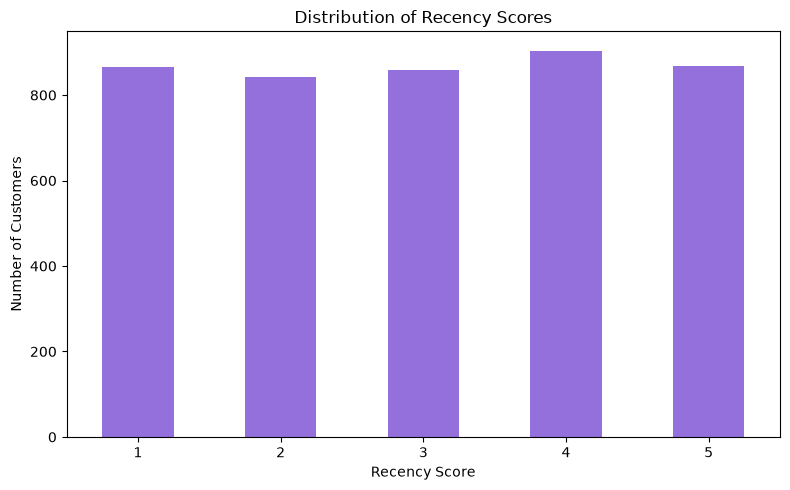

In [20]:
# Distribution of Recency Score

plt.figure(figsize=(8,5))

rfm["R_Score"].value_counts().sort_index().plot(
    kind="bar",
    color="mediumpurple"
)

plt.title("Distribution of Recency Scores")
plt.xlabel("Recency Score")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

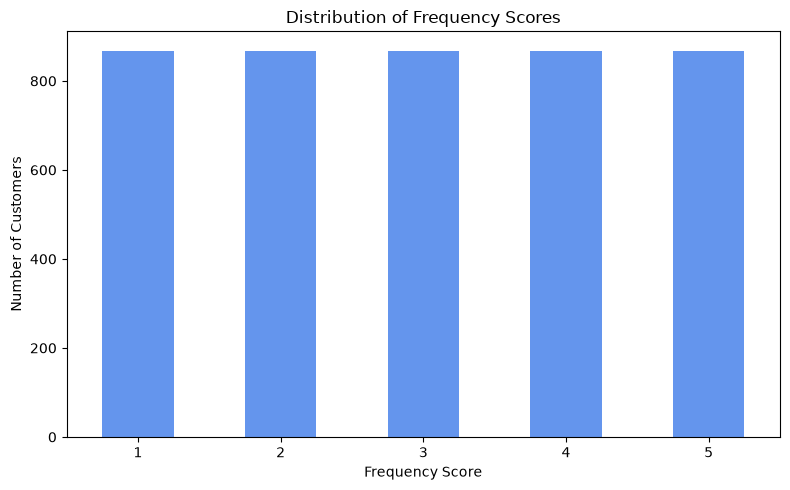

In [21]:
# Distribution of Frequency Score

plt.figure(figsize=(8,5))

rfm["F_Score"].value_counts().sort_index().plot(
    kind="bar",
    color="cornflowerblue"
)

plt.title("Distribution of Frequency Scores")
plt.xlabel("Frequency Score")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

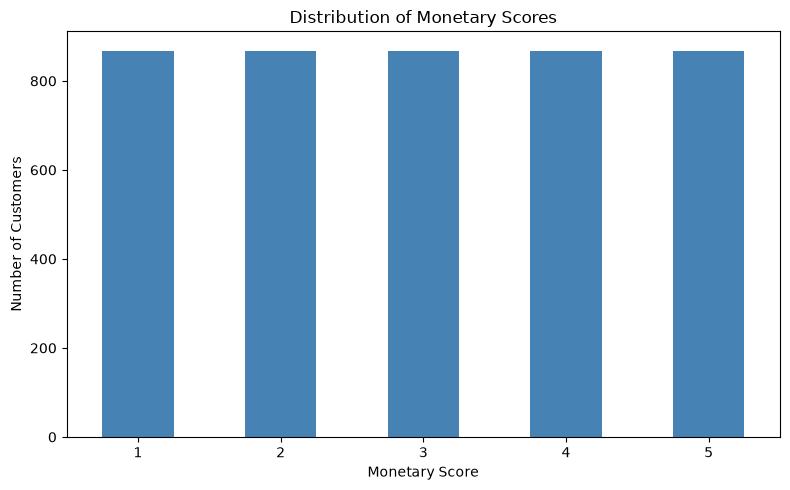

In [22]:
# Distribution of Monetary Score

plt.figure(figsize=(8,5))

rfm["M_Score"].value_counts().sort_index().plot(
    kind="bar",
    color="steelblue"
)

plt.title("Distribution of Monetary Scores")
plt.xlabel("Monetary Score")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observations

- Customers are distributed across five score levels for each RFM metric.
- Higher Recency scores indicate more recent customer activity.
- Higher Frequency scores represent customers who purchase more often.
- Higher Monetary scores represent customers with greater total spending.
- These standardized scores are now ready to be used for customer segmentation.

## Export RFM Dataset

For future analysis or dashboard development.

In [24]:
# Save RFM dataset

rfm.to_csv("../data/rfm_table.csv",index=False)

## Key Business Insights

- RFM metrics successfully summarize each customer's purchasing behavior.
- Recency identifies how recently customers made a purchase.
- Frequency measures customer purchase activity.
- Monetary represents total customer spending.
- These features will be used in the next notebook to perform KMeans clustering and identify customer groups.

## Marketing Recommendations

- Use the engineered RFM features to identify similar customer groups.
- Apply clustering techniques to discover high-value and at-risk customers.
- Use the identified customer groups for targeted marketing campaigns.
- The next notebook will build these customer segments using KMeans clustering.

In [25]:
rfm.reset_index().head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment
0,12346,326,1,77183.60,1,1,5,115,11
1,12347,2,7,4310.00,5,5,5,555,55
2,12348,75,4,1797.24,2,4,4,244,24
3,12349,19,1,1757.55,4,1,4,414,41
4,12350,310,1,334.40,1,1,2,112,11


# Conclusion

This notebook prepared the RFM features required for customer segmentation. In the next notebook, KMeans clustering will use these features to group customers into meaningful business segments such as High-Value, Regular, Occasional, and At-Risk.

### Observation

The RFM analysis summarizes each customer's purchasing behavior using Recency, Frequency, and Monetary value.

These features will be used in the next notebook to build a K-Means clustering model that automatically groups customers into business-friendly segments:
- High-Value
- Regular
- Occasional
- At-Risk